# Predicting Survival in the Titanic Data Set

In [14]:
# 1. Choose a class of model.
from sklearn import tree

In [15]:
# 2. Choose model hyperparameters.
model = tree.DecisionTreeClassifier(criterion='entropy')
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [16]:
# Read data from CSV file ระวัง ; และ ,
import pandas as pd
df = pd.read_csv('kidney_dataset.csv')
print(df.head())

   Creatinine        BUN         GFR  Urine_Output  Diabetes  Hypertension  \
0    0.788803   8.386869  102.161787   1632.649387         0             0   
1    3.413970  53.688796   50.071257    935.540516         1             0   
2    0.647645   7.466540   89.451831   1774.553846         1             1   
3    0.795508  12.516821   99.872180   2360.602980         0             0   
4    0.869010  19.855960   86.110182   1987.750901         0             1   

         Age  Protein_in_Urine  Water_Intake     Medication  CKD_Status  
0  27.682074        106.700203      1.570370            NaN           0  
1  33.122208        410.008362      3.425287  ACE Inhibitor           1  
2  55.832284        123.336925      1.123301       Diuretic           0  
3  32.391900        116.098870      3.086846  ACE Inhibitor           0  
4  66.689515         55.668760      2.174980            ARB           0  


In [17]:
# Get the shape of your DataFrame – the number of rows and columns using .shape,
print(df.shape)

# and the number of dimensions using .ndim.
print(df.ndim)

# You can check the types of each column in our example
# with the ‘.dtypes’ property of the dataframe.
print(df.dtypes)

#prints information about a DataFrame
print(df.info())

#object คือ string

(5000, 11)
2
Creatinine          float64
BUN                 float64
GFR                 float64
Urine_Output        float64
Diabetes              int64
Hypertension          int64
Age                 float64
Protein_in_Urine    float64
Water_Intake        float64
Medication           object
CKD_Status            int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   ob

In [18]:
# Total missing values for each feature
df.isnull().sum()

Creatinine             0
BUN                    0
GFR                    0
Urine_Output           0
Diabetes               0
Hypertension           0
Age                    0
Protein_in_Urine       0
Water_Intake           0
Medication          2987
CKD_Status             0
dtype: int64

<Axes: >

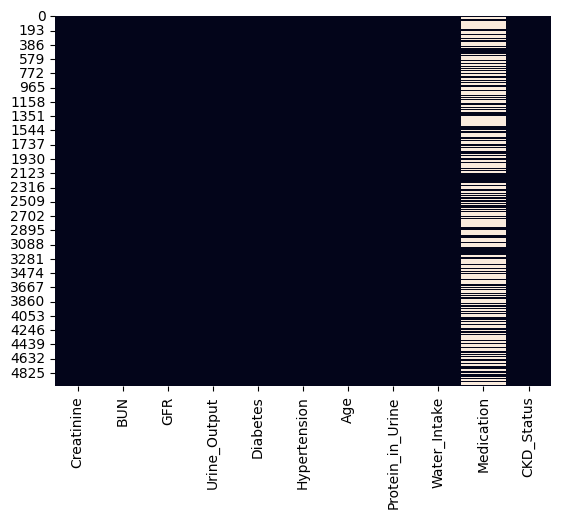

In [19]:
# Visualizing the patterns of missing value occurrence
# seaborn.heatmap

import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   object 
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 429.8+ KB
None


In [36]:
print(df.columns)


Index(['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension',
       'Age', 'Protein_in_Urine', 'Water_Intake', 'Medication', 'CKD_Status'],
      dtype='object')


In [38]:
df.columns = df.columns.str.strip()


In [39]:
# ลบช่องว่าง
df.columns = df.columns.str.strip()

# ทำให้เป็นตัวเล็กทั้งหมด
df.columns = df.columns.str.lower()

print(df.columns)


Index(['creatinine', 'bun', 'gfr', 'urine_output', 'diabetes', 'hypertension',
       'age', 'protein_in_urine', 'water_intake', 'medication', 'ckd_status'],
      dtype='object')


In [40]:
df = df[['age',
         'creatinine',
         'bun',
         'gfr',
         'diabetes',
         'hypertension',
         'protein_in_urine',
         'ckd_status']]


In [45]:
print(df.columns)


Index(['age', 'creatinine', 'bun', 'gfr', 'diabetes', 'hypertension',
       'protein_in_urine', 'ckd_status'],
      dtype='object')


In [ ]:
print(df.info())

In [ ]:
# 3. Arrange data into a features matrix and target vector.
X = df.drop('Survived', axis=1)
y = df['Survived']

In [46]:
df.columns = df.columns.str.strip()   # ลบช่องว่าง
df.columns = df.columns.str.lower()   # ทำเป็นตัวเล็กทั้งหมด

print(df.columns)


Index(['age', 'creatinine', 'bun', 'gfr', 'diabetes', 'hypertension',
       'protein_in_urine', 'ckd_status'],
      dtype='object')


In [47]:
print(df['age'].isnull().sum())


0


Columns: Index(['creatinine', 'bun', 'gfr', 'urine_output', 'diabetes', 'hypertension',
       'age', 'protein_in_urine', 'water_intake', 'medication', 'ckd_status'],
      dtype='object')
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       715
           1       1.00      1.00      1.00       285

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[715   0]
 [  0 285]]


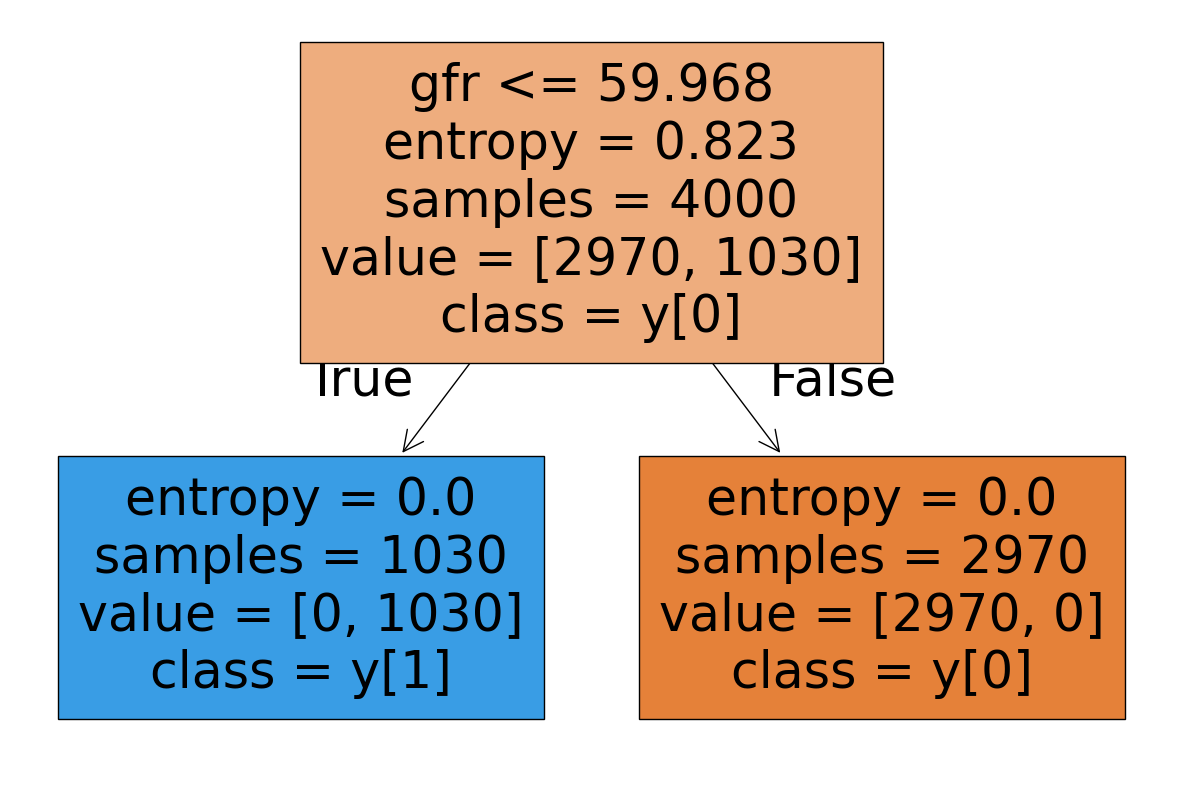

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------
# 1) Load dataset
# -----------------------
df = pd.read_csv("kidney_dataset.csv")

# ทำความสะอาดชื่อคอลัมน์
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

# -----------------------
# 2) จัดการ missing values
# -----------------------

# เติมค่ากลางสำหรับตัวเลข
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# ถ้ามี object ให้แปลงเป็นตัวเลข
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = pd.factorize(df[col])[0]

# -----------------------
# 3) แยก X และ y
# -----------------------

# สมมติ target ชื่อ ckd_status
X = df.drop('ckd_status', axis=1)
y = df['ckd_status']

# -----------------------
# 4) Train / Test Split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 5) สร้างและ Train โมเดล
# -----------------------
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------
# 6) ทำนายผล
# -----------------------
y_pred = model.predict(X_test)

# -----------------------
# 7) แสดง Accuracy
# -----------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------
# 8) แสดงกราฟ Decision Tree
# -----------------------
plt.figure(figsize=(15,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)
plt.show()


In [54]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ใช้ predict_proba
y_prob = model.predict_proba(X_test)[:, 1]

# คำนวณ AUC
auc = roc_auc_score(y_test, y_prob)
print("AUC =", auc)


AUC = 1.0


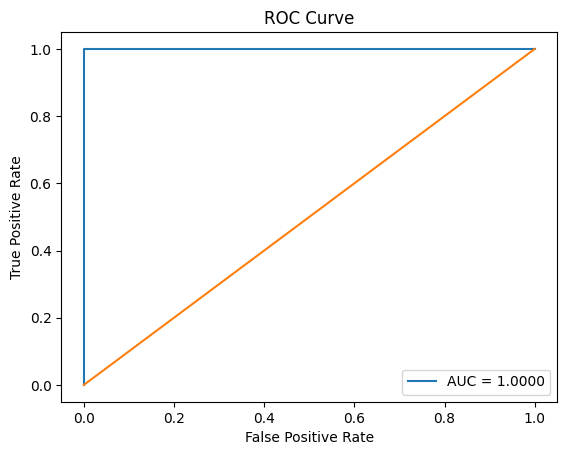

In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1])  # เส้นทแยง (random model)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
